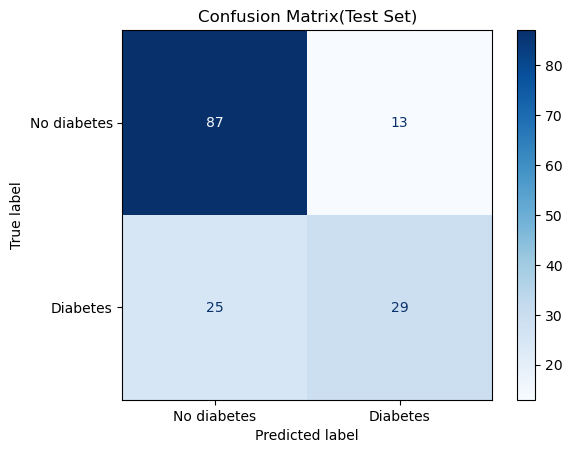

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



In [15]:
# Naive Bayes on diabetes dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes.csv')
x = df.drop('Outcome',axis=1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=101, stratify=y)

scaler = StandardScaler()
x_train['Insulin']=scaler.fit_transform(x_train[['Insulin']])
x_test['Insulin']=scaler.transform(x_test[['Insulin']])

model = GaussianNB()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=['No diabetes','Diabetes']).plot(cmap='Blues')
plt.title('Confusion Matrix(Test Set)')
plt.show()
print(classification_report(y_test, y_pred))